# From allele counts to an error-aware MAF estimate

We ask one question. What fraction of the sampled chromosome copies carries the alternate allele? When this frequency is at most $1/2$, it is the **minor allele frequency (MAF)**.

## Start from first principles

- Each diploid person contributes two alleles.
- A genotype dosage $g_i\in\{0,1,2\}$ counts alternate alleles.
- Known genotypes can be counted directly.
- Uncertain genotypes must be averaged over before counting.

This worked example connects **allele frequency, genotype dosage, HWE, genotype uncertainty, and genotyping error** with **counting, likelihood, MLE, latent genotypes, and EM**.


## 1. Known genotypes can be counted

Code a genotype as $g_i\in\{0,1,2\}$, the number of alternate alleles carried by person $i$. With $n$ diploid people, the sample contains $2n$ chromosome copies. Therefore

$$
\widehat f_{\text{count}}=\frac{\sum_{i=1}^n g_i}{2n}.
$$

This calculation uses the observed genotype as the true genotype. We will relax that assumption below.


In [1]:
# Five people at one biallelic variant: 0 = CC, 1 = CT, 2 = TT
g_exact <- c(0, 2, 1, 0, 0)
n <- length(g_exact)
alt_alleles <- sum(g_exact)
f_count <- alt_alleles / (2 * n)
maf_count <- min(f_count, 1 - f_count)

data.frame(n_people = n, alt_alleles = alt_alleles,
           alt_frequency = f_count, MAF = maf_count)


n_people,alt_alleles,alt_frequency,MAF
<int>,<dbl>,<dbl>,<dbl>
5,3,0.3,0.3


## 2. The allele count is also the HWE MLE

Under Hardy--Weinberg equilibrium (HWE), let $f$ be the alternate-allele frequency. A true genotype is generated as

$$
P(G_i=0\mid f)=(1-f)^2,\qquad
P(G_i=1\mid f)=2f(1-f),\qquad
P(G_i=2\mid f)=f^2.
$$

For exact observed genotypes, the likelihood is

$$
L(f)=\prod_i P(G_i=g_i\mid f).
$$

If the data contain $n_0,n_1,n_2$ people with genotypes 0, 1, and 2, then

$$
L(f)\propto f^{n_1+2n_2}(1-f)^{2n_0+n_1}.
$$

Maximizing this likelihood gives $\widehat f=(n_1+2n_2)/(2n)$. **The allele count is therefore the MLE when the genotypes are known.**


In [2]:
hwe_prob <- function(f) {
  c(G0 = (1 - f)^2, G1 = 2 * f * (1 - f), G2 = f^2)
}

loglik_exact <- function(f, g) {
  sum(log(hwe_prob(f)[g + 1]))
}

fit_exact <- optimize(loglik_exact, interval = c(1e-6, 1 - 1e-6),
                      maximum = TRUE, g = g_exact)
f_mle <- fit_exact$maximum

data.frame(method = c("direct allele count", "HWE maximum likelihood"),
           estimate = c(f_count, f_mle))


method,estimate
<chr>,<dbl>
direct allele count,0.3000000
HWE maximum likelihood,0.2999942


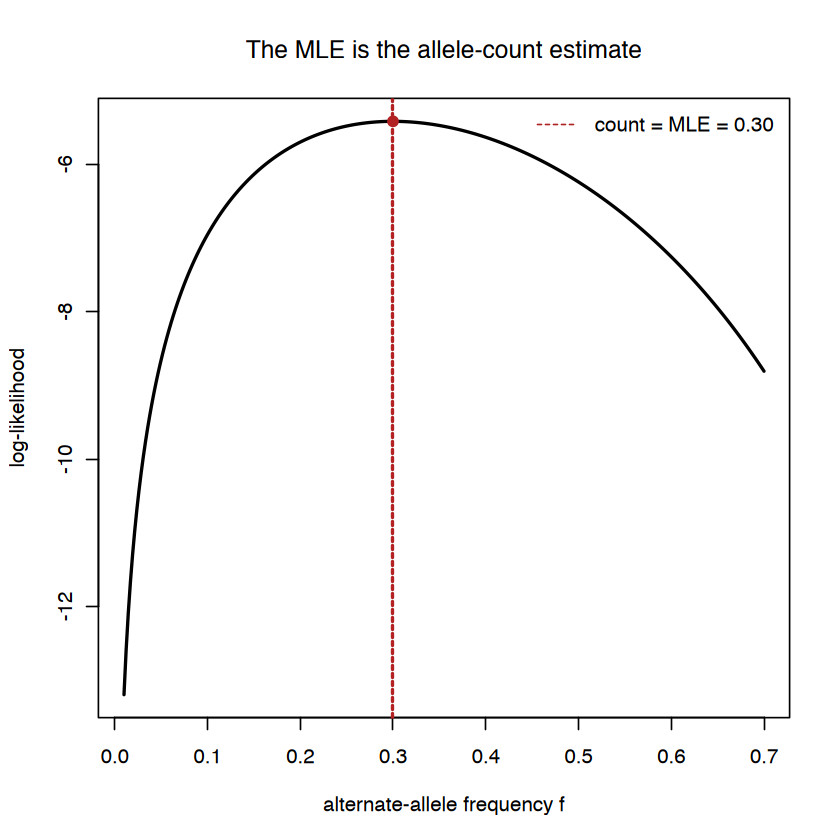

In [3]:
f_grid <- seq(0.01, 0.70, length.out = 300)
ll_grid <- vapply(f_grid, loglik_exact, numeric(1), g = g_exact)

plot(f_grid, ll_grid, type = "l", lwd = 2,
     xlab = "alternate-allele frequency f", ylab = "log-likelihood",
     main = "The MLE is the allele-count estimate")
abline(v = f_count, col = "firebrick", lty = 2, lwd = 2)
points(f_mle, fit_exact$objective, pch = 19, col = "firebrick")
legend("topright", legend = sprintf("count = MLE = %.2f", f_count),
       lty = 2, col = "firebrick", bty = "n")


### Insight behind the approach

The likelihood reproduces allele counting when genotypes are known. It also lets us add a model for how the genotype was measured.


## 3. Genotyping error makes the true genotype hidden

The **true genotype** $G_i$ generates the **observed genotype call** $D_i$ through two steps.

$$
f \longrightarrow G_i \longrightarrow D_i.
$$

1. $G_i$ is generated from the HWE probabilities determined by $f$.
2. With probability $\epsilon$, the calling process makes an error event and assigns one of the three calls at random. Thus

$$
P(D_i=d\mid G_i=g,\epsilon)=
\begin{cases}
1-2\epsilon/3, & d=g,\\
\epsilon/3, & d\ne g.
\end{cases}
$$

This simple error model keeps the calculation visible. A sequencing analysis can use read-level genotype likelihoods in place of this call-error matrix.


In [4]:
# Simulation with known truth.
set.seed(581)
f_true <- 0.30
epsilon_true <- 0.05
n <- 10000

g_true <- sample(0:2, n, replace = TRUE, prob = hwe_prob(f_true))
d_observed <- g_true
error_event <- runif(n) < epsilon_true
d_observed[error_event] <- sample(0:2, sum(error_event), replace = TRUE)

observed_counts <- table(factor(d_observed, levels = 0:2))
n <- length(d_observed)

f_observed_count <- sum(d_observed) / (2 * n)

data.frame(observed_call = 0:2, count = as.integer(observed_counts))
cat(sprintf("True MAF: %.3f\n", f_true))
cat(sprintf("Direct count of observed calls: %.3f\n", f_observed_count))
cat(sprintf("Simulated error events: %d of %d\n", sum(error_event), n))


observed_call,count
<int>,<int>
0,4781
1,4175
2,1044


True MAF: 0.300


Direct count of observed calls: 0.313


Simulated error events: 494 of 10000


The direct count treats each observed call as the true genotype. In this simulation, the true genotypes are hidden from the estimator but retained so that we can check the answer. The error-aware likelihood sums over the three possible true genotypes.

$$
L(f,\epsilon)=\prod_{i=1}^n\sum_{g=0}^2
P(D_i=d_i\mid G_i=g,\epsilon)P(G_i=g\mid f).
$$

EM applies this calculation to every person through repeated **soft counting**.

### E-step infers each hidden genotype

$$
w_{ig}=P(G_i=g\mid D_i=d_i,f,\epsilon)
\propto P(D_i=d_i\mid G_i=g,\epsilon)P(G_i=g\mid f).
$$

### M-step recounts expected alleles and errors

$$
f^{\text{new}}=\frac{1}{2n}\sum_i(w_{i1}+2w_{i2}),\qquad
\epsilon^{\text{new}}=\frac{3}{2n}\sum_i[1-w_{i,d_i}].
$$

**The key idea** is simple. Replace each hidden genotype by posterior weights, then count with those weights.


In [5]:
error_matrix <- function(epsilon) {
  out <- matrix(epsilon / 3, 3, 3,
                dimnames = list(observed = 0:2, true = 0:2))
  diag(out) <- 1 - 2 * epsilon / 3
  out
}

joint_genotype_prob <- function(d, f, epsilon) {
  error_matrix(epsilon)[d + 1, , drop = FALSE] *
    rep(hwe_prob(f), each = length(d))
}

genotype_weights <- function(d, f, epsilon) {
  joint <- joint_genotype_prob(d, f, epsilon)
  joint / rowSums(joint)
}

observed_loglik <- function(d, f, epsilon) {
  sum(log(rowSums(joint_genotype_prob(d, f, epsilon))))
}

em_update <- function(d, f, epsilon) {
  weight <- genotype_weights(d, f, epsilon)
  expected_dosage <- as.numeric(weight %*% (0:2))
  posterior_match <- weight[cbind(seq_along(d), d + 1)]
  c(
    f = mean(expected_dosage) / 2,
    epsilon = min(1 - 1e-10, 1.5 * mean(1 - posterior_match))
  )
}

fit_em <- function(d, f = mean(d) / 2, epsilon = 0.05,
                   tolerance = 1e-10, max_iterations = 10000) {
  history <- data.frame(
    iteration = 0, f = f, epsilon = epsilon,
    loglik = observed_loglik(d, f, epsilon)
  )

  for (iteration in seq_len(max_iterations)) {
    updated <- em_update(d, f, epsilon)
    f_new <- updated[["f"]]
    epsilon_new <- updated[["epsilon"]]
    history <- rbind(history, data.frame(
      iteration = iteration, f = f_new, epsilon = epsilon_new,
      loglik = observed_loglik(d, f_new, epsilon_new)
    ))

    change <- max(abs(c(f_new - f, epsilon_new - epsilon)))
    f <- f_new
    epsilon <- epsilon_new
    if (change < tolerance) break
  }

  list(
    f = f, epsilon = epsilon,
    posterior = genotype_weights(d, f, epsilon),
    history = history
  )
}


In [6]:
em_fit <- fit_em(d_observed)

data.frame(
  parameter = c("MAF f", "error rate epsilon"),
  truth = c(f_true, epsilon_true),
  direct_count = c(f_observed_count, NA),
  EM = c(em_fit$f, em_fit$epsilon)
)

tail(em_fit$history, 5)


parameter,truth,direct_count,EM
<chr>,<dbl>,<dbl>,<dbl>
MAF f,0.30,0.31315,0.3027498
error rate epsilon,0.05,NA,0.0527257


,iteration,f,epsilon,loglik
,<dbl>,<dbl>,<dbl>,<dbl>
580,579,0.3027498,0.0527257,-9533.754
581,580,0.3027498,0.0527257,-9533.754
582,581,0.3027498,0.0527257,-9533.754
583,582,0.3027498,0.0527257,-9533.754
584,583,0.3027498,0.0527257,-9533.754


,observed_call,P(true=0),P(true=1),P(true=2)
0,0,0.9811,0.0155,0.0034
1,1,0.0205,0.9757,0.0039
2,2,0.0818,0.0711,0.8471


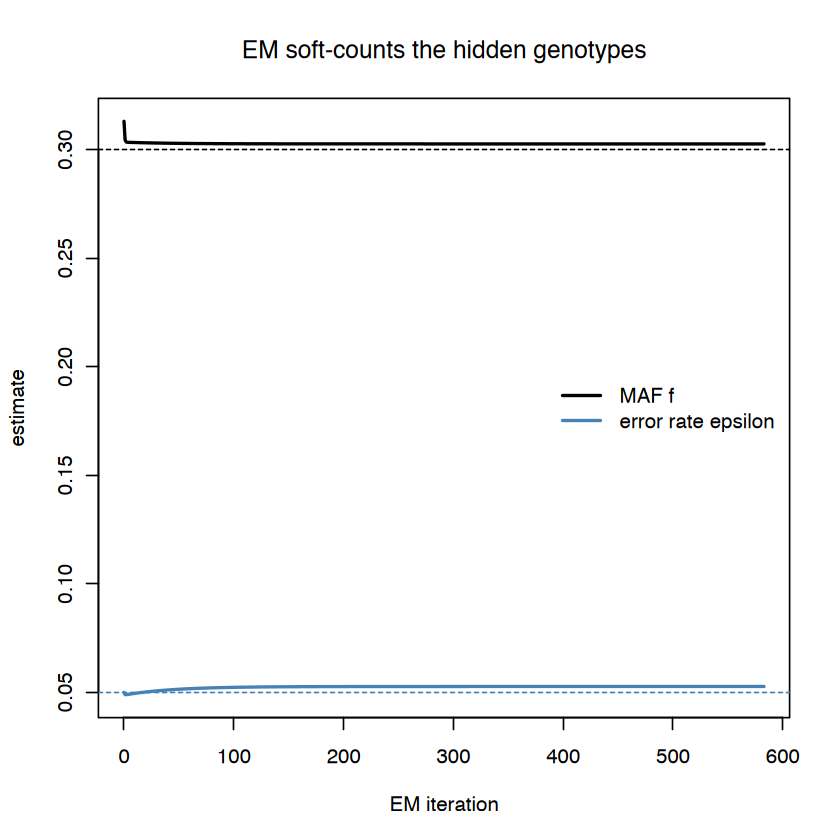

In [7]:
posterior_by_call <- cbind(
  observed_call = 0:2,
  genotype_weights(0:2, em_fit$f, em_fit$epsilon)
)
colnames(posterior_by_call) <- c("observed_call",
                                 "P(true=0)", "P(true=1)", "P(true=2)")
round(posterior_by_call, 4)

matplot(em_fit$history$iteration,
        em_fit$history[, c("f", "epsilon")],
        type = "l", lty = 1, lwd = 2,
        col = c("black", "steelblue"),
        xlab = "EM iteration", ylab = "estimate",
        main = "EM soft-counts the hidden genotypes")
abline(h = c(f_true, epsilon_true), lty = 2,
       col = c("black", "steelblue"))
legend("right", legend = c("MAF f", "error rate epsilon"),
       col = c("black", "steelblue"), lty = 1, lwd = 2, bty = "n")


## 4. Check the answer two ways

Direct optimization of the same observed-data likelihood should agree with EM. The observed-data log-likelihood should also increase or remain unchanged at every EM iteration.


In [8]:
negative_loglik <- function(par, d) {
  -observed_loglik(d, f = par["f"], epsilon = par["epsilon"])
}

direct_fit <- optim(
  par = c(f = 0.30, epsilon = 0.05),
  fn = negative_loglik,
  d = d_observed,
  method = "L-BFGS-B",
  lower = c(1e-6, 1e-6),
  upper = c(0.5 - 1e-6, 1 - 1e-6)
)

comparison <- data.frame(
  parameter = c("MAF f", "error rate epsilon"),
  truth = c(f_true, epsilon_true),
  EM = c(em_fit$f, em_fit$epsilon),
  direct_optimization = direct_fit$par
)
comparison$difference <- comparison$EM - comparison$direct_optimization
comparison

stopifnot(direct_fit$convergence == 0)
stopifnot(max(abs(comparison$difference)) < 1e-4)
stopifnot(all(diff(em_fit$history$loglik) >= -1e-8))
cat("Checks passed: EM agrees with direct optimization, and likelihood is monotone.\n")


,parameter,truth,EM,direct_optimization,difference
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
f,MAF f,0.30,0.3027498,0.30275000,-1.554361e-07
epsilon,error rate epsilon,0.05,0.0527257,0.05272776,-2.059572e-06


Checks passed: EM agrees with direct optimization, and likelihood is monotone.


## What to remember

1. **Concept and intuition.** Allele frequency counts chromosome copies. Known genotypes give an ordinary allele count.
2. **Insight behind the approach.** A likelihood can include the measurement process. EM replaces each hidden genotype by posterior weights and then recounts alleles and errors.
3. **Worked example.** With known simulation parameters, EM recovers the MAF and error rate. It also agrees with direct likelihood optimization.

The error-aware estimate is useful when the error model describes the measurement process.

## Source record and further detail

- **Classification.** Course example.
- The genotyping-error simulation uses seed 581, $n=10{,}000$, true MAF $0.30$, and true error rate $0.05$. The result is checked by direct likelihood optimization.
- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 1.3, especially allele frequency, genotype coding, and HWE.
- Lecture 2 slides in `modules/human_popgen/genotype_data.tex`
